# Solute Transport Convergence (d=40): mPCN, pCN, EP-pCN, MESS, ESS, EP-ESS

This is the real convergence experiment notebook for the d=40 setup (`config_id=2`).

It loads existing chains from `mcmc-internal/estimations` and `mess-internal/estimations`, computes trace and running-MSE overlays, and writes explicit warnings when expected chains are missing locally.

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for cand in [start] + list(start.parents):
        if (cand / 'mcmc-internal').exists() and (cand / 'mess-internal').exists():
            return cand
    return start


def resolve_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent and not (cur / 'pyproject.toml').exists():
        cur = cur.parent
    return cur


cwd = Path.cwd().resolve()
repo_root = resolve_repo_root(cwd)
workspace_root = find_workspace_root(repo_root)
mess_internal_root = workspace_root / 'mess-internal'
mcmc_internal_root = workspace_root / 'mcmc-internal'

for src in [mess_internal_root / 'src', mcmc_internal_root / 'src']:
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))

from mess.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
    AdvectionDiffusionToy,
)

print('workspace_root:', workspace_root)
print('mess_internal_root exists:', mess_internal_root.exists())
print('mcmc_internal_root exists:', mcmc_internal_root.exists())

workspace_root: /Users/guillers/Documents/GitHub/mcmc
mess_internal_root exists: True
mcmc_internal_root exists: True


In [3]:
config_id = 2
configurations = {
    1: {'d': 20, 'obs_highest_freq': 8, 'obs_bandwidth': 5},
    2: {'d': 40, 'obs_highest_freq': 12, 'obs_bandwidth': 7},
    3: {'d': 60, 'obs_highest_freq': 16, 'obs_bandwidth': 9},
    4: {'d': 40, 'obs_highest_freq': 8, 'obs_bandwidth': 5},
}
cfg = configurations[config_id]

d = cfg['d']
obs_highest_freq = cfg['obs_highest_freq']
obs_bandwidth = cfg['obs_bandwidth']

seed_data = 0
seed_mcmc = 202
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'

rho_ref = 0.9
P_ref = 100
burn_in = 5000
max_iter_mse = 1000
max_replicates = 50

reports_dir = mess_internal_root / 'reports' / 'jcgs-notebooks' / f'convergence_d{d}_config{config_id}'
reports_dir.mkdir(parents=True, exist_ok=True)

print('config_id:', config_id)
print('d:', d)
print('obs_highest_freq:', obs_highest_freq, 'obs_bandwidth:', obs_bandwidth)
print('reports_dir:', reports_dir)

config_id: 2
d: 40
obs_highest_freq: 12 obs_bandwidth: 7
reports_dir: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/convergence_d40_config2


In [4]:
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def build_problem(dim, seed):
    rng = np.random.default_rng(seed)
    m = dim * (dim - 1) // 2
    prior_diag = prior_diag_from_powerlaw(dim, alpha=alpha, gamma=gamma, tau2=tau2, offset=1.0)

    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(dim, beta=alpha, c=2.0 ** (-gamma), offset=1.0)
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
    else:
        a_true = rng.standard_normal(m) * np.sqrt(prior_diag)

    g = np.zeros(dim, dtype=float)
    g[0] = 1.0
    theta_true = solve_theta(dim, a_true, g, kappa)
    noise = rng.standard_normal(dim)
    obs_idx = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    y = theta_true[obs_idx] + sigma * noise[obs_idx]

    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=y,
        obs_indices=obs_idx,
        g=g,
        prior_diag=prior_diag,
    )

    return {'problem': problem, 'a_true': a_true, 'obs_indices': obs_idx}


problem_data = build_problem(d, seed_data)
problem = problem_data['problem']
a_true = problem_data['a_true']

print('Problem dimension:', problem.dim)
print('n_obs:', len(problem_data['obs_indices']))

Problem dimension: 780
n_obs: 7


In [5]:
warnings = []


def add_warning(msg):
    warnings.append(msg)
    print('WARNING:', msg)


def load_chain(path):
    with np.load(path, allow_pickle=False) as npz:
        return np.asarray(npz['chain'], dtype=float)


def pick_latest_convergence_run(base_dir):
    if not base_dir.exists():
        return None
    candidates = sorted(base_dir.glob('mpcn_pcn_convergence_h*'))
    return candidates[-1] if candidates else None


rho_tag = f'{rho_ref:.5f}'.replace('.', 'p')

mcmc_fixed_root = mcmc_internal_root / 'estimations' / 'solute_transport' / 'data_h4afe80f670cc' / 'fixed'
mcmc_run_dir = pick_latest_convergence_run(mcmc_fixed_root)
if mcmc_run_dir is None:
    add_warning('Did not find local mPCN/pCN convergence run under mcmc-internal estimations (data_h4afe80f670cc/fixed).')

mess_ad_root = mess_internal_root / 'estimations' / 'AD_toy_dim_M_sweep_shared_draws'
mess_ad_runs = sorted(mess_ad_root.glob('priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_dmax100_Niters*'))
mess_ad_run = mess_ad_runs[-1] if mess_ad_runs else None
if mess_ad_run is None:
    add_warning('Did not find local MESS AD shared-draw run under mess-internal estimations/AD_toy_dim_M_sweep_shared_draws.')

print('mcmc_run_dir:', mcmc_run_dir)
print('mess_ad_run:', mess_ad_run)

mcmc_run_dir: /Users/guillers/Documents/GitHub/mcmc/mcmc-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hf7e75042285f
mess_ad_run: /Users/guillers/Documents/GitHub/mcmc/mess-internal/estimations/AD_toy_dim_M_sweep_shared_draws/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_dmax100_Niters500000


In [6]:
chains = {
    'mPCN': [],
    'pCN': [],
    'EP-pCN': [],
    'MESS': [],
    'ESS': [],
    'EP-ESS': [],
}

if mcmc_run_dir is not None:
    mpcn_dir = mcmc_run_dir / 'chains' / 'mpcn_independent'
    pcn_dir = mcmc_run_dir / 'chains' / 'independent_chains'

    mpcn_files = sorted(mpcn_dir.glob(f'mpcn_P{P_ref}_rho{rho_tag}_seed*_chain*.npz')) if mpcn_dir.exists() else []
    pcn_files = sorted(pcn_dir.glob(f'pcn_independent_rho{rho_tag}_seed*_chain*.npz')) if pcn_dir.exists() else []

    if not mpcn_files:
        add_warning(f'Did not find mPCN chains for P={P_ref}, rho={rho_ref} in {mpcn_dir}.')
    if not pcn_files:
        add_warning(f'Did not find pCN independent chains for rho={rho_ref} in {pcn_dir}.')

    for fp in mpcn_files[:max_replicates]:
        chains['mPCN'].append(load_chain(fp))
    for fp in pcn_files[:max_replicates]:
        chains['pCN'].append(load_chain(fp))

    if len(pcn_files) >= P_ref:
        ep_list = []
        for fp in pcn_files[:P_ref]:
            c = load_chain(fp)
            ep_list.append(c[::P_ref])
        chains['EP-pCN'] = ep_list
    else:
        add_warning(f'Not enough independent pCN chains to form EP-pCN with P={P_ref} (found {len(pcn_files)}).')

if mess_ad_run is not None:
    mess_file = mess_ad_run / f'chain_d{d}_mess_M{P_ref}.npz'
    ess_file = mess_ad_run / f'chain_d{d}_mess_M1.npz'

    if mess_file.exists():
        chains['MESS'].append(load_chain(mess_file))
    else:
        add_warning(f'Did not find MESS chain {mess_file.name} in {mess_ad_run}.')

    if ess_file.exists():
        chains['ESS'].append(load_chain(ess_file))
    else:
        add_warning(f'Did not find ESS-equivalent chain {ess_file.name} in {mess_ad_run}.')

    ep_ess_files = sorted(mess_ad_run.glob(f'chain_d{d}_ess_independent_seed*_chain*.npz'))
    if ep_ess_files:
        for fp in ep_ess_files[:P_ref]:
            chains['EP-ESS'].append(load_chain(fp))
    else:
        add_warning('Did not find independent ESS chains for EP-ESS aggregation.')

print('Loaded chain counts:')
for k, v in chains.items():
    print(f'- {k}: {len(v)}')

Loaded chain counts:
- mPCN: 34
- pCN: 50
- EP-pCN: 100
- MESS: 0
- ESS: 0
- EP-ESS: 0


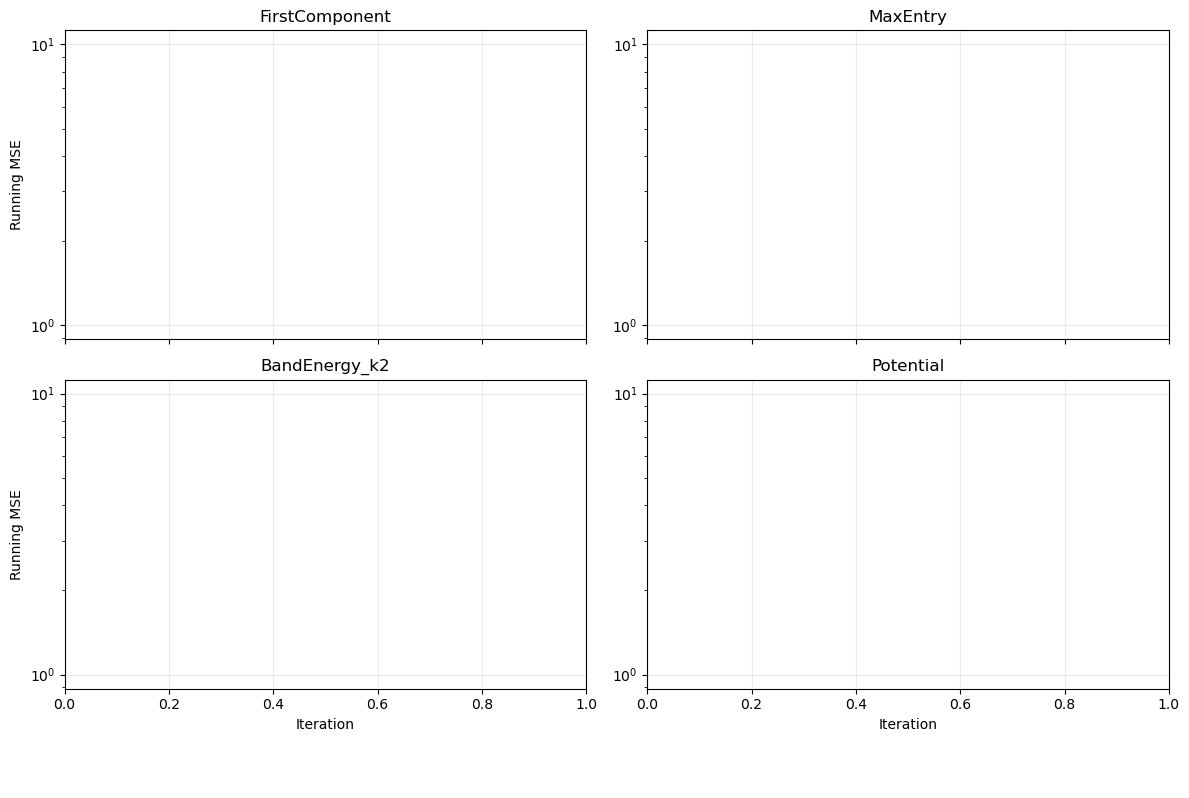

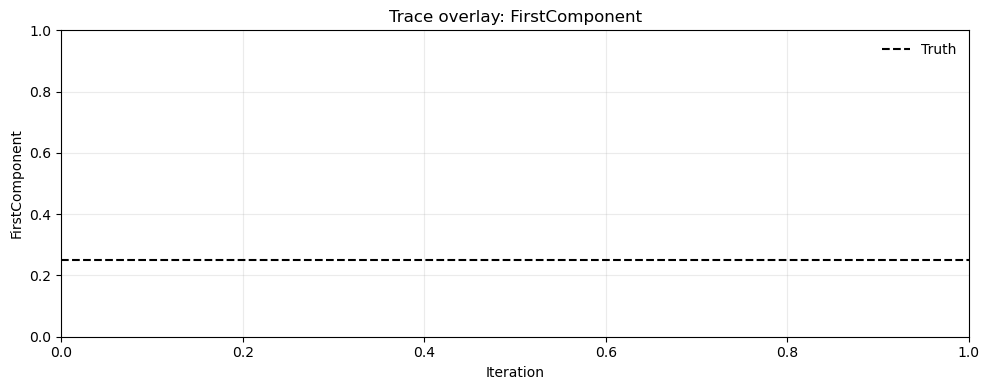

Saved: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/convergence_d40_config2/solute_transport_running_mse_d40_rho0.90_P100.png
Saved: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/convergence_d40_config2/solute_transport_trace_overlay_d40_rho0.90_P100.png


In [7]:
def band_energy_k2(params):
    A = make_Astar_from_atrue(d, params)
    e = 0.0
    for i in range(d):
        for j in range(i + 1, d):
            if abs(j - i) <= 2:
                e += A[i, j] ** 2
    return float(e)


obs_defs = {
    3: ('FirstComponent', lambda p: float(p[0])),
    102: ('MaxEntry', lambda p: float(np.max(np.abs(p)))),
    101: ('BandEnergy_k2', band_energy_k2),
    8: ('Potential', lambda p: float(-problem.log_likelihood(p))),
}
obs_ids = [3, 102, 101, 8]
targets = {obs_id: obs_defs[obs_id][1](a_true) for obs_id in obs_ids}


def running_mse_for_chain(chain, obs_fn, target, n_iter):
    vals = np.asarray([obs_fn(x) for x in chain], dtype=float)
    vals = vals[min(burn_in, len(vals)):]
    vals = vals[:n_iter]
    if vals.size == 0:
        return np.array([], dtype=float)
    running_mean = np.cumsum(vals) / np.arange(1, vals.size + 1)
    return (running_mean - target) ** 2


def mean_trace_for_chain(chain, obs_fn, n_iter):
    vals = np.asarray([obs_fn(x) for x in chain], dtype=float)
    vals = vals[min(burn_in, len(vals)):]
    return vals[:n_iter]


def aggregate_curves(chain_list, obs_fn, target, n_iter):
    curves = [running_mse_for_chain(c, obs_fn, target, n_iter) for c in chain_list]
    curves = [c for c in curves if c.size > 0]
    if not curves:
        return np.array([], dtype=float)
    n = min(len(c) for c in curves)
    stacked = np.stack([c[:n] for c in curves], axis=0)
    return np.mean(stacked, axis=0)


def aggregate_traces(chain_list, obs_fn, n_iter):
    traces = [mean_trace_for_chain(c, obs_fn, n_iter) for c in chain_list]
    traces = [t for t in traces if t.size > 0]
    if not traces:
        return np.array([], dtype=float)
    n = min(len(t) for t in traces)
    stacked = np.stack([t[:n] for t in traces], axis=0)
    return np.mean(stacked, axis=0)


available_methods = {k: v for k, v in chains.items() if len(v) > 0}
if not available_methods:
    raise ValueError('No chains were found locally for any method. See warnings above.')

method_colors = {
    'mPCN': '#1f77b4',
    'pCN': '#2ca02c',
    'EP-pCN': '#17becf',
    'MESS': '#d62728',
    'ESS': '#ff7f0e',
    'EP-ESS': '#9467bd',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, obs_id in enumerate(obs_ids):
    name, fn = obs_defs[obs_id]
    ax = axes[i]
    for method, chain_list in available_methods.items():
        curve = aggregate_curves(chain_list, fn, targets[obs_id], max_iter_mse)
        if curve.size > 0:
            ax.plot(curve, label=method, color=method_colors.get(method), linewidth=2)
    ax.set_title(name)
    ax.set_yscale('log')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Running MSE')
axes[2].set_ylabel('Running MSE')
axes[2].set_xlabel('Iteration')
axes[3].set_xlabel('Iteration')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
mse_path = reports_dir / f'solute_transport_running_mse_d{d}_rho{rho_ref:.2f}_P{P_ref}.png'
fig.savefig(mse_path, dpi=300, bbox_inches='tight')
plt.show()

trace_obs_id = 3
trace_name, trace_fn = obs_defs[trace_obs_id]
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 4))
for method, chain_list in available_methods.items():
    t = aggregate_traces(chain_list, trace_fn, max_iter_mse)
    if t.size > 0:
        ax2.plot(t, label=method, color=method_colors.get(method), linewidth=2)
ax2.axhline(targets[trace_obs_id], color='black', linestyle='--', linewidth=1.5, label='Truth')
ax2.set_title(f'Trace overlay: {trace_name}')
ax2.set_xlabel('Iteration')
ax2.set_ylabel(trace_name)
ax2.grid(alpha=0.25)
ax2.legend(frameon=False)
trace_path = reports_dir / f'solute_transport_trace_overlay_d{d}_rho{rho_ref:.2f}_P{P_ref}.png'
fig2.tight_layout()
fig2.savefig(trace_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', mse_path)
print('Saved:', trace_path)

In [8]:
warning_payload = {
    'config_id': config_id,
    'd': d,
    'rho_ref': rho_ref,
    'P_ref': P_ref,
    'warnings': warnings,
}
warning_path = reports_dir / 'missing_chain_warnings.json'
with open(warning_path, 'w', encoding='utf-8') as f:
    json.dump(warning_payload, f, indent=2)

print('Warning file:', warning_path)
if warnings:
    print('Summary: some local chain families are missing. See warning file for details.')
else:
    print('Summary: all expected chain families were found locally.')

Warning file: /Users/guillers/Documents/GitHub/mcmc/mess-internal/reports/jcgs-notebooks/convergence_d40_config2/missing_chain_warnings.json
Summary: some local chain families are missing. See warning file for details.
